# Ejercicio 4

Utilizando pyTerrier, indexe la colección Wiki-Small . Tome 5 necesidades de información y, de forma manual, derive una consulta (query). Para cada una, pruebe la recuperación por los modelos basados en TF/IDF y BM25. ¿Cómo se comportan los rankings? Calcule el coeficiente de correlación para los primeros 10, 25 y 50 resultados. ¿Qué conclusiones obtiene?

## Inicializacion de Terrier

In [ ]:
import pandas as pd
import pyterrier as pt
if not pt.java.started():
  pt.java.init()

## Procesamiento de WIKI-SMALL con BeautifulSoup

Algoritmo provisto por el equipo docente

In [7]:
import os
from bs4 import BeautifulSoup

def extract_text_from_html(filepath:str):
  with open(filepath, "r", encoding="utf-8") as file:
    soup = BeautifulSoup(file,"html.parser")
    return soup.get_text(separator=" ", strip= True)

def process_wiki_collection(root_dir: str) -> dict:
  documents = {}
  for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
      if filename.endswith(".html"):
        full_path = os.path.join(dirpath,filename)
        relative_path = os.path.relpath(full_path, root_dir)
        try:
          text = extract_text_from_html(full_path)
          documents[relative_path] = text
        except Exception as e:
          print(f"Error leyendo {full_path}: {e}")
  return documents

root_directory = "../Colecciones/en/articles/"
docs_wiki = process_wiki_collection(root_directory)

# Muestra primeras 50 caracteres
for path, content in list(docs_wiki.items())[:3]:
  print(f"{path} ->")
  print(content[:50], "...") #

(\1\5\(15810)_1994_JR1_9064.html ->
(15810) 1994 JR1 - Wikipedia, the free encyclopedi ...
0\_\(\0_(number).html ->
0 (number) - Wikipedia, the free encyclopedia 0 (n ...
1\,\5\1,5-anhydro-D-fructose_reductase_0c7b.html ->
1,5-anhydro-D-fructose reductase - Wikipedia, the  ...


## Preparacion de documento a Indexar

In [12]:
#Pasaje a dataframe

data = []
for path, content in docs_wiki.items():
    data.append({
        "docno": path,   # ID del documento
        "text": content  # contenido
    })

df_docs = pd.DataFrame(data)

df_docs.head()

,docno,text
0,(\1\5\(15810)_1994_JR1_9064.html,"(15810) 1994 JR1 - Wikipedia, the free encyclo..."
1,0\_\(\0_(number).html,"0 (number) - Wikipedia, the free encyclopedia ..."
2,"1\,\5\1,5-anhydro-D-fructose_reductase_0c7b.html","1,5-anhydro-D-fructose reductase - Wikipedia, ..."
3,1\0\0\100th_Anniversary_deb0.html,"100th Anniversary - Wikipedia, the free encycl..."
4,1\0\4\10440_van_Swinden_fef9.html,"10440 van Swinden - Wikipedia, the free encycl..."


## Indexacion de la Coleccion

In [19]:
#Crear el indexador - Ruta absoluta
index_path = os.path.abspath("index_wiki_small")

# Crear carpeta si no existe
os.makedirs(index_path, exist_ok=True)

print("Index path:", index_path)

indexer = pt.IterDictIndexer(index_path, overwrite=True, meta={'docno': 256})

# Escanea el documento, tokeniza y escribe los archivos a binario en el disco
indexref = indexer.index(df_docs.to_dict(orient="records"))

# Carga estructuras clave en memoria (vocabulario, estadísticas, etc.)
index = pt.IndexFactory.of(indexref)
print(index.collectionStatistics)

Index path: c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP2\EJ4\index_wiki_small


01:24:02.484 [main] ERROR org.terrier.structures.indexing.Indexer -- Could not rename index
java.io.IOException: Rename of index structure file 'c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP2\EJ4\index_wiki_small/data_1.direct.bf' (exists) to 'c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP2\EJ4\index_wiki_small/data.direct.bf' (exists) failed - likely that source file is still open. Possible indexing bug?
	at org.terrier.structures.IndexUtil.renameIndex(IndexUtil.java:379)
	at org.terrier.structures.indexing.Indexer.index(Indexer.java:388)
Number of documents: 6043
Number of terms: 164927
Number of postings: 1563535
Number of fields: 0
Number of tokens: 2870991
Field names: []
Positions:   false



In [ ]:
# termino: 
# term5: Es el ID interno del término. Terrier asigna un número único 
# Nt=2: (Document Frequency) 
# TF=2: (Total Term Frequency) cf
# maxTF=1: Es la frecuencia máxima que alcanzó el termino un solo documento
# @{0 0 6} ID del archivo  (si el índice está dividido), desplazamiento (offset) en bytes
# bit exacto.


for kv in index.getLexicon():
  print(f"{kv.getKey()}: {kv.getValue().toString()}")

## Modelos de Recuperacion

TF-IDF

In [22]:
tfidf = pt.terrier.Retriever(index, wmodel="TF_IDF")

BM25

In [23]:
bm25 = pt.terrier.Retriever(index, wmodel="BM25")

## Necesidades de informacion

In [48]:
# La necesidad de informacion fue construida seleccionando cualquier archivo y eligiendo palabras al azar que puede resultar de interes para la consulta
# queries = pd.DataFrame([
#     ["1", "canada 1838 montreal"],
#     ["2", "asteroid 1994"],
#     ["3", "wikipedia languages"],
#     ["4", "world war"],
#     ["5", "foo fighters"]
# ], columns=["qid", "query"])

queries = pd.DataFrame([
    ["1", "solar system dwarf planet"],
    ["2", "number theory prime numbers"],
    ["3", "enzyme metabolic process"],
    ["4", "world war history"],
    ["5", "programming languages types"]
], columns=["qid", "query"])

queries

,qid,query
0,1,solar system dwarf planet
1,2,number theory prime numbers
2,3,enzyme metabolic process
3,4,world war history
4,5,programming languages types


In [49]:
#results = tfidf.search("canada 1838 montreal")
#results

# Transform deveulte todos los rankings para todas las queries
res_tfidf = tfidf.transform(queries)
res_bm25 = bm25.transform(queries)

for qid in queries["qid"]:
    print(f"\n====================")
    print(f"Query {qid}: {queries[queries['qid']==qid]['query'].values[0]}")
    
    print("\nTF-IDF:")
    print(res_tfidf[res_tfidf["qid"] == qid][["docno","score","rank"]].head(10))
    
    print("\nBM25:")
    print(res_bm25[res_bm25["qid"] == qid][["docno","score","rank"]].head(10))


Query 1: solar system dwarf planet

TF-IDF:
                                       docno      score  rank
0                  2\9\1\2919_Dali_18e3.html  20.169534     0
1                  1\1\2\1127_Mimi_6c39.html  19.040284     1
2              1\8\8\18883_Domegge_08fa.html  19.028427     2
3           (\1\5\(15810)_1994_JR1_9064.html  18.339534     3
4                3\1\1\311_Claudia_d3e5.html  18.059840     4
5                  i\k\_\IK_Pegasi_d64d.html  16.885243     5
6        c\o\n\Confederacy_of_Suns_26e4.html  10.393818     6
7         c\u\s\Custer_Observatory_f5ea.html   9.710999     7
8      l\e\o\Leo_II_(dwarf_galaxy)_9c73.html   9.692112     8
9  a\_\j\A_Journey_in_Other_Worlds_286f.html   9.543454     9

BM25:
                                       docno      score  rank
0                  2\9\1\2919_Dali_18e3.html  36.175876     0
1                  1\1\2\1127_Mimi_6c39.html  34.151985     1
2              1\8\8\18883_Domegge_08fa.html  34.130714     2
3           (\1\5\

## Coeficiente de Correlacion

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def ranking_correlation(res1, res2, qid, k):
    r1 = res1[res1["qid"] == qid].head(k)
    r2 = res2[res2["qid"] == qid].head(k)

    merged = pd.merge(r1, r2, on="docno", suffixes=("_1", "_2"))

    # Si hay poco overlap, no se puede calcular bien
    if len(merged) < 2:
        return np.nan

    return spearmanr(merged["rank_1"], merged["rank_2"]).correlation

In [58]:
ks = [10, 25, 50]

# Calcular correlaciones
results = []

for qid in queries["qid"]:
    for k in ks:
        corr = ranking_correlation(res_tfidf, res_bm25, qid, k)
        results.append({
            "qid": qid,
            "k": k,
            "correlation": corr
        })

df_corr = pd.DataFrame(results)
results

[{'qid': '1', 'k': 10, 'correlation': 0.9878787878787878},
 {'qid': '1', 'k': 25, 'correlation': 0.9930434782608695},
 {'qid': '1', 'k': 50, 'correlation': 0.9961840888066605},
 {'qid': '2', 'k': 10, 'correlation': 0.9333333333333332},
 {'qid': '2', 'k': 25, 'correlation': 0.9426877470355731},
 {'qid': '2', 'k': 50, 'correlation': 0.9574440052700921},
 {'qid': '3', 'k': 10, 'correlation': 0.9878787878787878},
 {'qid': '3', 'k': 25, 'correlation': 0.9992307692307693},
 {'qid': '3', 'k': 50, 'correlation': 0.9979831932773109},
 {'qid': '4', 'k': 10, 'correlation': 0.9636363636363635},
 {'qid': '4', 'k': 25, 'correlation': 0.9723076923076923},
 {'qid': '4', 'k': 50, 'correlation': 0.9886018237082066},
 {'qid': '5', 'k': 10, 'correlation': 0.8285714285714287},
 {'qid': '5', 'k': 25, 'correlation': 0.5405138339920948},
 {'qid': '5', 'k': 50, 'correlation': 0.743954480796586}]

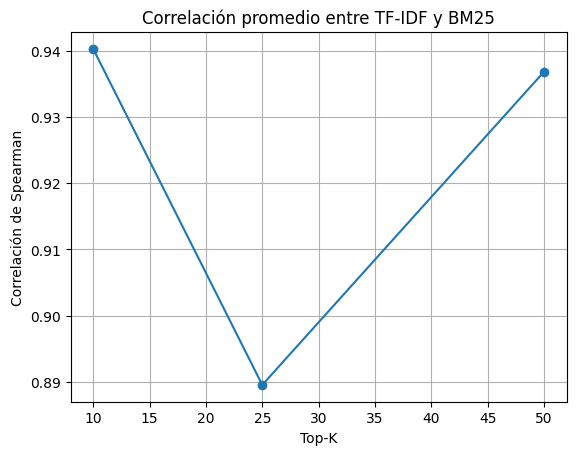

In [59]:
# Promedio por k
avg_corr = df_corr.groupby("k")["correlation"].mean().reset_index()

# 📈 Gráfico principal (promedio)
plt.figure()
plt.plot(avg_corr["k"], avg_corr["correlation"], marker='o')
plt.xlabel("Top-K")
plt.ylabel("Correlación de Spearman")
plt.title("Correlación promedio entre TF-IDF y BM25")
plt.grid()
plt.show()